<a href="https://colab.research.google.com/github/uyenndt1210/thuchanh-deeplearning/blob/main/Buoi4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Autoencoder

## Import thư viện

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    UpSampling2D
)
from tensorflow.keras.models import Model

## Load CIFAR-10

In [3]:
(x_train, _), (x_test, _) = cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Train:", x_train.shape)
print("Test :", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Train: (50000, 32, 32, 3)
Test : (10000, 32, 32, 3)


## Xây dựng Encoder

In [4]:
input_img = Input(shape=(32,32,3))

x = Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(input_img)

x = MaxPooling2D(
    (2,2),
    padding='same'
)(x)

x = Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = MaxPooling2D(
    (2,2),
    padding='same'
)(x)

x = Conv2D(
    128,
    (3,3),
    activation='relu',
    padding='same'
)(x)

encoded = MaxPooling2D(
    (2,2),
    padding='same'
)(x)

## Xây dựng Decoder

In [5]:
x = Conv2D(
    128,
    (3,3),
    activation='relu',
    padding='same'
)(encoded)

x = UpSampling2D((2,2))(x)

x = Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = UpSampling2D((2,2))(x)

x = Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = UpSampling2D((2,2))(x)

decoded = Conv2D(
    3,
    (3,3),
    activation='sigmoid',
    padding='same'
)(x)

## Tạo Autoencoder

In [6]:
autoencoder = Model(
    input_img,
    decoded
)

autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

## Huấn luyện

In [7]:
history = autoencoder.fit(
    x_train,
    x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - loss: 0.5887 - val_loss: 0.5743
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.5720 - val_loss: 0.5703
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.5689 - val_loss: 0.5673
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.5664 - val_loss: 0.5654
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.5642 - val_loss: 0.5643
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.5630 - val_loss: 0.5630
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.5620 - val_loss: 0.5621
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.5613 - val_loss: 0.5614
Epoch 9/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.5609 - val_loss: 0.5614
Epoch 10/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.5605 - val_loss: 0.5624
Epoch 11/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.5598 - val_loss: 0.5603
Epoch 12/20
391/391 ━━━━━━━━━━━━━━━━━━━━

In [8]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,001,867 (3.82 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 667,912 (2.55 MB)

## Vẽ biểu đồ Loss

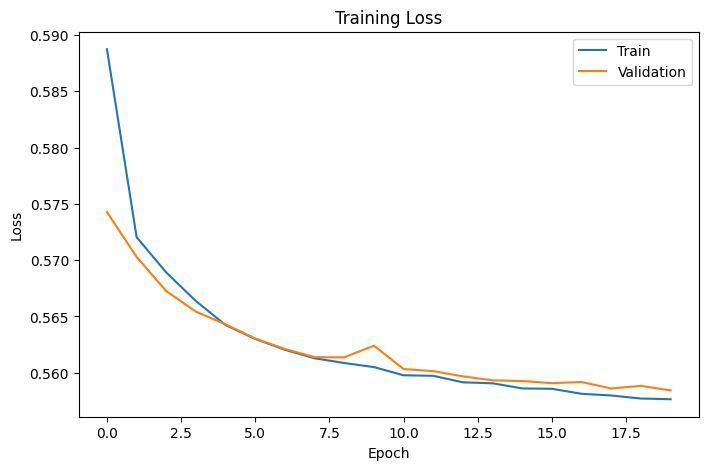

In [9]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train','Validation'])

plt.show()

## Tái tạo ảnh

In [10]:
decoded_imgs = autoencoder.predict(x_test[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 879ms/step


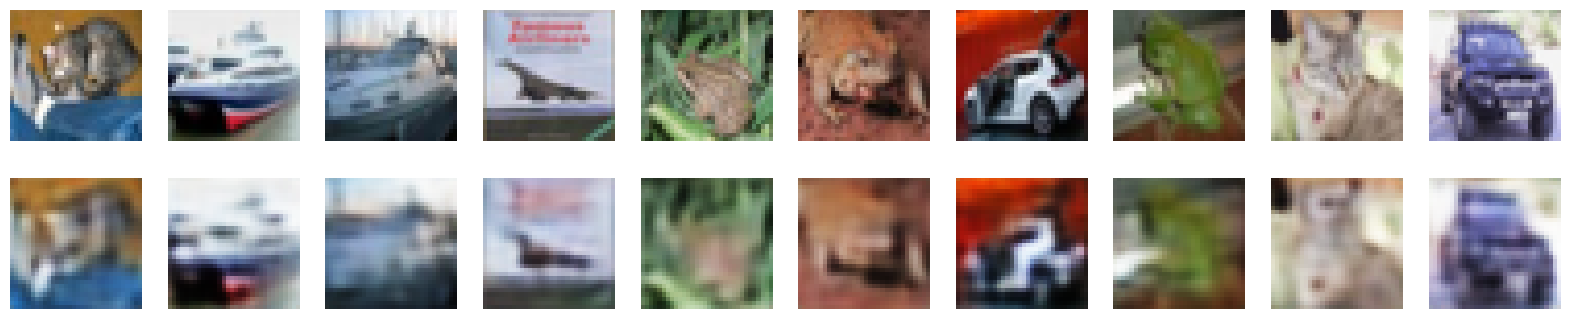

In [11]:
plt.figure(figsize=(20,4))

for i in range(10):

    ax = plt.subplot(
        2,
        10,
        i+1
    )

    plt.imshow(x_test[i])
    plt.axis('off')

    ax = plt.subplot(
        2,
        10,
        i+11
    )

    plt.imshow(decoded_imgs[i])
    plt.axis('off')

plt.show()

# RNN

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

In [ ]:
months = pd.date_range(
    start="2020-01-01",
    periods=60,
    freq="ME"
)

prices = np.linspace(
    150000,
    350000,
    60
) + np.random.randint(-5000, 5000, 60)

df = pd.DataFrame({
    "month": months.strftime("%Y-%m"),
    "price": prices.astype(int)
})

df.to_csv("raw_sales.csv", index=False)

print(df.head())
print("Đã lưu raw_sales.csv")

     month   price
0  2020-01  154625
1  2020-02  154556
2  2020-03  160048
3  2020-04  156271
4  2020-05  160242
Đã lưu raw_sales.csv


## Đọc dữ liệu

In [ ]:
df = pd.read_csv("raw_sales.csv")

prices = df["price"].values.reshape(-1,1)

## Chuẩn hóa

In [ ]:
scaler = MinMaxScaler()

prices_scaled = scaler.fit_transform(prices)


## Tạo dữ liệu chuỗi

In [ ]:
def get_XY(data, time_steps):

    X = []
    Y = []

    for i in range(len(data)-time_steps):

        X.append(data[i:i+time_steps])

        Y.append(data[i+time_steps])

    return np.array(X), np.array(Y)

time_steps = 12

X, Y = get_XY(prices_scaled, time_steps)

## Chia train test

In [ ]:
train_size = int(len(X)*0.8)

X_train = X[:train_size]
Y_train = Y[:train_size]

X_test = X[train_size:]
Y_test = Y[train_size:]

print(X_train.shape)
print(Y_train.shape)

(38, 12, 1)
(38, 1)


## Xây dựng RNN

In [ ]:
model = Sequential()

model.add(
    SimpleRNN(
        32,
        activation='tanh',
        input_shape=(time_steps,1)
    )
)

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

## Train

In [ ]:
history = model.fit(
    X_train,
    Y_train,
    epochs=100,
    batch_size=4,
    validation_data=(X_test,Y_test)
)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 140ms/step - loss: 0.0814 - val_loss: 0.1174
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0125 - val_loss: 0.0021
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0068 - val_loss: 0.0393
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0037 - val_loss: 0.0110
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0028 - val_loss: 0.0153
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0016 - val_loss: 0.0118
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0014 - val_loss: 0.0100
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0013 - val_loss: 0.0087
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0012 - val_loss: 0.0083
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0010 - val_loss: 0.0055
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0010 - val_loss: 0.0068
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/ste

## Dự báo

In [ ]:
pred = model.predict(X_test)

pred_real = scaler.inverse_transform(pred)

Y_test_real = scaler.inverse_transform(Y_test)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step


## RMSE

In [ ]:
rmse = np.sqrt(
    mean_squared_error(
        Y_test_real,
        pred_real
    )
)

print("RMSE =", rmse)


RMSE = 7000.993129619294


## Loss

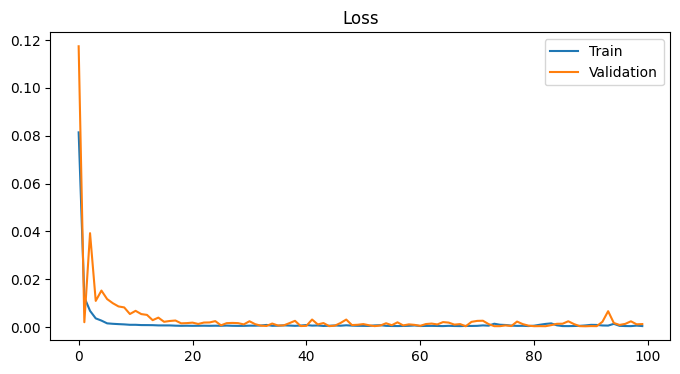

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train','Validation'])
plt.title("Loss")
plt.show()


## So sánh kết quả

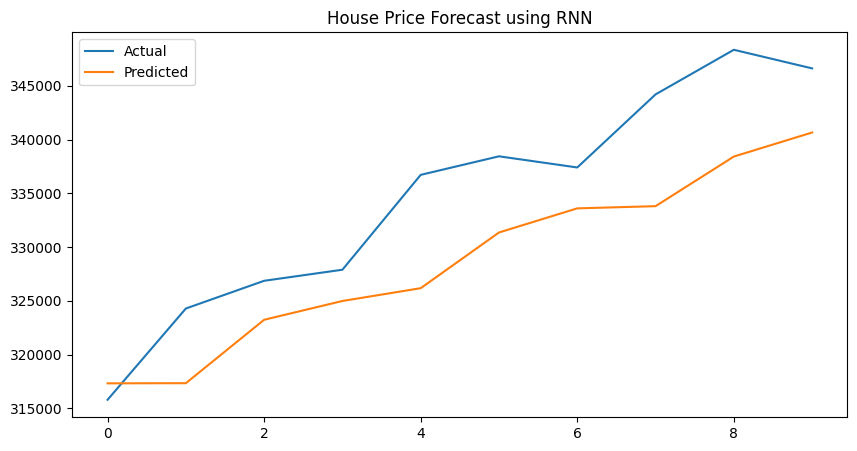

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    Y_test_real,
    label="Actual"
)

plt.plot(
    pred_real,
    label="Predicted"
)

plt.legend()
plt.title("House Price Forecast using RNN")
plt.show()